In [1]:
import sys

print(sys.executable)

e:\Retail-Sales-Analytics\.venv\Scripts\python.exe


In [ ]:
# Retail Sales Analytics Platform

## Phase 1: Data Exploration

### Objective
#The objective of this notebook is to understand the retail dataset before designing the PostgreSQL database and ETL pipeline.

### Tasks
#- Load the dataset
#- Explore the structure
#- Analyze data quality
#- Identify business entities
#- Prepare for database design

In [3]:
import pandas as pd
import numpy as np

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully 🚀")

Libraries Imported Successfully 🚀


In [10]:
import os

print("Current Working Directory:")
print(os.getcwd())

Current Working Directory:
e:\Retail-Sales-Analytics


In [11]:
print("Files in current directory:")
print(os.listdir())

print("\nFiles in data folder:")
print(os.listdir("data"))

print("\nFiles in raw folder:")
print(os.listdir("data/raw"))

Files in current directory:
['.venv', 'dashboard', 'data', 'docs', 'etl', 'notebooks', 'README.md', 'reports', 'requirements.txt', 'screenshots', 'sql']

Files in data folder:
['processed', 'raw']

Files in raw folder:
['Global Superstore.xlsx']


In [12]:
import pandas as pd

df = pd.read_excel("data/raw/Global Superstore.xlsx")

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,41121,41121,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,United States,10024.0,US,East,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,41310,41312,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,Australia,NaN,APAC,Oceania,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,41564,41565,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,Australia,NaN,APAC,Oceania,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium
3,13524,ES-2013-1579342,41302,41304,First Class,KM-16375,Katherine Murray,Home Office,Berlin,Berlin,Germany,NaN,EU,Central,TEC-PH-10004583,Technology,Phones,"Motorola Smart Phone, Cordless",2892.510,5,0.1,-96.5400,910.16,Medium
4,47221,SG-2013-4320,41583,41584,Same Day,RH-9495,Rick Hansen,Consumer,Dakar,Dakar,Senegal,NaN,Africa,Africa,TEC-SHA-10000501,Technology,Copiers,"Sharp Wireless Fax, High-Speed",2832.960,8,0.0,311.5200,903.04,Critical


In [13]:
# Number of rows and columns
print("Dataset Shape")
print(df.shape)

Dataset Shape
(51290, 24)


In [14]:
# Column names
df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'City', 'State', 'Country',
       'Postal Code', 'Market', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit', 'Shipping Cost', 'Order Priority'],
      dtype='object')

In [15]:
# Information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  int64  
 3   Ship Date       51290 non-null  int64  
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [16]:
# Statistical summary
df.describe()

,Row ID,Order Date,Ship Date,Postal Code,Sales,Quantity,Discount,Profit,Shipping Cost
count,51290.00000,51290.000000,51290.000000,9994.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,41405.893624,41409.862995,55190.379428,246.490581,3.476545,0.142908,28.610982,26.375818
std,14806.29199,412.557888,412.558057,32063.693350,487.565361,2.278766,0.212280,174.340972,57.296810
min,1.00000,40544.000000,40546.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000,0.002000
25%,12823.25000,41079.000000,41083.000000,23223.000000,30.758625,2.000000,0.000000,0.000000,2.610000
50%,25645.50000,41463.000000,41467.000000,56430.500000,85.053000,3.000000,0.000000,9.240000,7.790000
75%,38467.75000,41781.000000,41785.000000,90008.000000,251.053200,5.000000,0.200000,36.810000,24.450000
max,51290.00000,42004.000000,42011.000000,99301.000000,22638.480000,14.000000,0.850000,8399.976000,933.570000


In [17]:
# Missing values
df.isnull().sum()

Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
City                  0
State                 0
Country               0
Postal Code       41296
Market                0
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Quantity              0
Discount              0
Profit                0
Shipping Cost         0
Order Priority        0
dtype: int64

In [18]:
# Duplicate records
df.duplicated().sum()

np.int64(0)

In [19]:
# Display the number of rows and columns in the dataset

rows, columns = df.shape

print(f"Number of Rows    : {rows}")
print(f"Number of Columns : {columns}")

Number of Rows    : 51290
Number of Columns : 24


In [20]:
# Display all column names

for i, column in enumerate(df.columns, start=1):
    print(f"{i}. {column}")

1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Customer Name
8. Segment
9. City
10. State
11. Country
12. Postal Code
13. Market
14. Region
15. Product ID
16. Category
17. Sub-Category
18. Product Name
19. Sales
20. Quantity
21. Discount
22. Profit
23. Shipping Cost
24. Order Priority


In [21]:
missing_values = df.isnull().sum()

missing_values[missing_values > 0]

Postal Code    41296
dtype: int64

In [ ]:
## Initial Observations
#- The dataset contains 51,290 transactions and 24 columns.
#- No duplicate records were found.
#- Missing values are present only in the `Postal Code` column.
#- Order Date and Ship Date require conversion to datetime format.
#- The dataset includes customer, product, order, location, and sales information, making it suitable for designing a star schema and building a retail analytics platform.

In [ ]:
# Convert Excel serial numbers to datetime

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    origin="1899-12-30",
    unit="D"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    origin="1899-12-30",
    unit="D"
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     9994 non-null   float64       
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [24]:
# Number of unique values in every column

unique_values = pd.DataFrame({
    "Column": df.columns,
    "Unique Values": df.nunique().values
})

unique_values

,Column,Unique Values
0,Row ID,51290
1,Order ID,25035
2,Order Date,1430
3,Ship Date,1464
4,Ship Mode,4
5,Customer ID,1590
6,Customer Name,795
7,Segment,3
8,City,3636
9,State,1094


In [31]:
df["Category"].unique()



array(['Technology', 'Furniture', 'Office Supplies'], dtype=object)

In [27]:
df["Segment"].unique()

array(['Consumer', 'Corporate', 'Home Office'], dtype=object)

In [26]:
df["Sub-Category"].unique()

array(['Accessories', 'Chairs', 'Phones', 'Copiers', 'Tables', 'Binders',
       'Supplies', 'Appliances', 'Machines', 'Bookcases', 'Storage',
       'Furnishings', 'Art', 'Paper', 'Envelopes', 'Fasteners', 'Labels'],
      dtype=object)

In [28]:
df["Ship Mode"].unique()

array(['Same Day', 'Second Class', 'First Class', 'Standard Class'],
      dtype=object)

In [29]:
df["Order Priority"].unique()

array(['Critical', 'Medium', 'High', 'Low'], dtype=object)

In [30]:
df["Market"].unique()

array(['US', 'APAC', 'EU', 'Africa', 'EMEA', 'LATAM', 'Canada'],
      dtype=object)

In [32]:
print("Total Orders :", df["Order ID"].nunique())
print("Total Customers :", df["Customer ID"].nunique())
print("Total Products :", df["Product ID"].nunique())
print("Total Countries :", df["Country"].nunique())

Total Orders : 25035
Total Customers : 1590
Total Products : 10292
Total Countries : 147


In [33]:
# Total Revenue

total_sales = df["Sales"].sum()

print(f"Total Sales: ${total_sales:,.2f}")

Total Sales: $12,642,501.91


In [34]:
total_profit = df["Profit"].sum()

print(f"Total Profit: ${total_profit:,.2f}")

Total Profit: $1,467,457.29


In [35]:
average_sales = df["Sales"].mean()

print(f"Average Sale per Transaction: ${average_sales:.2f}")

Average Sale per Transaction: $246.49


In [36]:
average_discount = df["Discount"].mean()

print(f"Average Discount: {average_discount:.2%}")

Average Discount: 14.29%


In [37]:
profit_margin = (total_profit / total_sales) * 100

print(f"Profit Margin: {profit_margin:.2f}%")

Profit Margin: 11.61%


In [ ]:
# Business KPI Analysis

## Objective

#Calculate the most important business metrics that summarize the performance of the retail business.

#These KPIs will later be displayed in the Power BI dashboard.

In [38]:
# Calculate total revenue

total_sales = df["Sales"].sum()

print(f"💰 Total Sales : ${total_sales:,.2f}")

💰 Total Sales : $12,642,501.91


In [39]:
# Calculate total profit

total_profit = df["Profit"].sum()

print(f"📈 Total Profit : ${total_profit:,.2f}")

📈 Total Profit : $1,467,457.29


In [40]:
# Calculate total shipping cost

total_shipping = df["Shipping Cost"].sum()

print(f"🚚 Total Shipping Cost : ${total_shipping:,.2f}")

🚚 Total Shipping Cost : $1,352,815.70


In [41]:
# Calculate average sales per transaction

average_sales = df["Sales"].mean()

print(f"🛒 Average Sale : ${average_sales:.2f}")

🛒 Average Sale : $246.49


In [42]:
# Calculate average discount

average_discount = df["Discount"].mean()

print(f"🏷 Average Discount : {average_discount:.2%}")

🏷 Average Discount : 14.29%


In [43]:
# Calculate profit margin

profit_margin = (total_profit / total_sales) * 100

print(f"📊 Profit Margin : {profit_margin:.2f}%")

📊 Profit Margin : 11.61%


In [44]:
category_sales = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order ID", "count")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

category_sales

,Total_Sales,Total_Profit,Total_Orders
Category,,,
Technology,4.744557e+06,663778.73318,10141
Furniture,4.110874e+06,285204.72380,9876
Office Supplies,3.787070e+06,518473.83430,31273


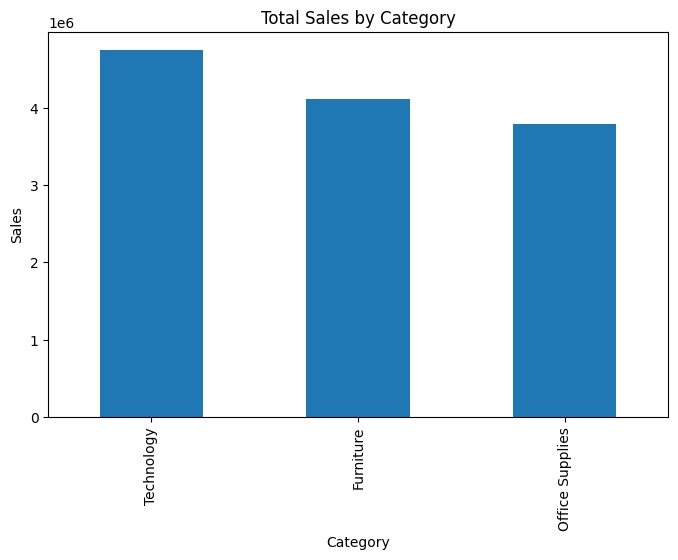

In [45]:
import matplotlib.pyplot as plt

category_sales["Total_Sales"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [46]:
# Sales by Category

category_sales = (
    df.groupby("Category")
      .agg(
          Total_Sales=("Sales", "sum"),
          Total_Profit=("Profit", "sum"),
          Total_Orders=("Order ID", "count")
      )
      .sort_values(by="Total_Sales", ascending=False)
)

category_sales

,Total_Sales,Total_Profit,Total_Orders
Category,,,
Technology,4.744557e+06,663778.73318,10141
Furniture,4.110874e+06,285204.72380,9876
Office Supplies,3.787070e+06,518473.83430,31273


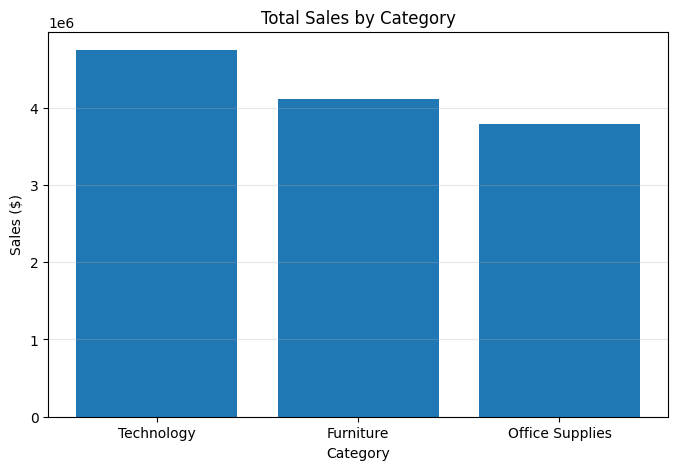

In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    category_sales.index,
    category_sales["Total_Sales"]
)

plt.title("Total Sales by Category")

plt.xlabel("Category")

plt.ylabel("Sales ($)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [48]:
category_profit = (
    df.groupby("Category")["Profit"]
      .sum()
      .sort_values(ascending=False)
)

category_profit

Category
Technology         663778.73318
Office Supplies    518473.83430
Furniture          285204.72380
Name: Profit, dtype: float64

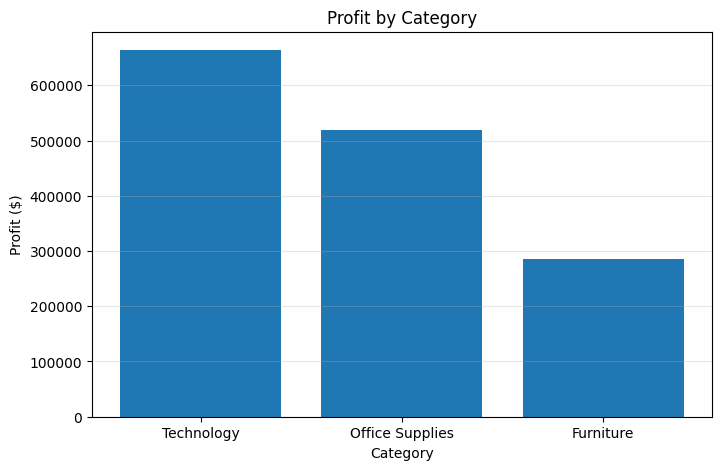

In [49]:
plt.figure(figsize=(8,5))

plt.bar(
    category_profit.index,
    category_profit.values
)

plt.title("Profit by Category")

plt.xlabel("Category")

plt.ylabel("Profit ($)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [50]:
market_sales = (
    df.groupby("Market")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

market_sales

Market
APAC      3.585744e+06
EU        2.938089e+06
US        2.297201e+06
LATAM     2.164605e+06
EMEA      8.061613e+05
Africa    7.837732e+05
Canada    6.692817e+04
Name: Sales, dtype: float64

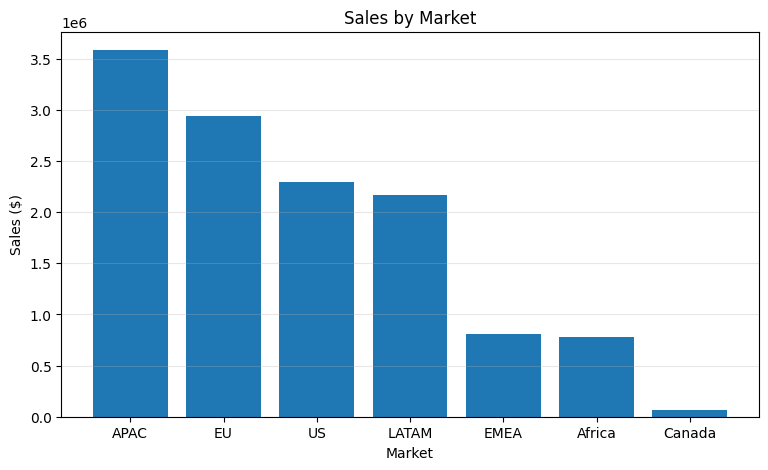

In [51]:
plt.figure(figsize=(9,5))

plt.bar(
    market_sales.index,
    market_sales.values
)

plt.title("Sales by Market")

plt.xlabel("Market")

plt.ylabel("Sales ($)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [52]:
segment_sales = (
    df.groupby("Segment")["Sales"]
      .sum()
      .sort_values(ascending=False)
)

segment_sales

Segment
Consumer       6.507949e+06
Corporate      3.824698e+06
Home Office    2.309855e+06
Name: Sales, dtype: float64

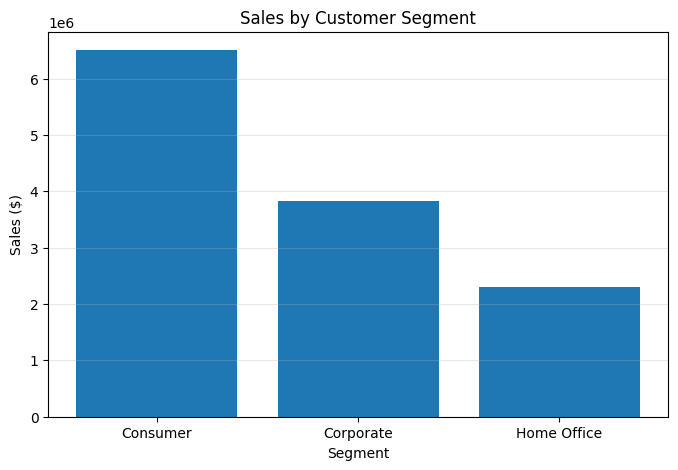

In [53]:
plt.figure(figsize=(8,5))

plt.bar(
    segment_sales.index,
    segment_sales.values
)

plt.title("Sales by Customer Segment")

plt.xlabel("Segment")

plt.ylabel("Sales ($)")

plt.grid(axis="y", alpha=0.3)

plt.show()

In [54]:
top_products = (
    df.groupby("Product Name")["Sales"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products

Product Name
Apple Smart Phone, Full Size                                86935.7786
Cisco Smart Phone, Full Size                                76441.5306
Motorola Smart Phone, Full Size                             73156.3030
Nokia Smart Phone, Full Size                                71904.5555
Canon imageCLASS 2200 Advanced Copier                       61599.8240
Hon Executive Leather Armchair, Adjustable                  58193.4841
Office Star Executive Leather Armchair, Adjustable          50661.6840
Harbour Creations Executive Leather Armchair, Adjustable    50121.5160
Samsung Smart Phone, Cordless                               48653.4600
Nokia Smart Phone, with Caller ID                           47877.7857
Name: Sales, dtype: float64

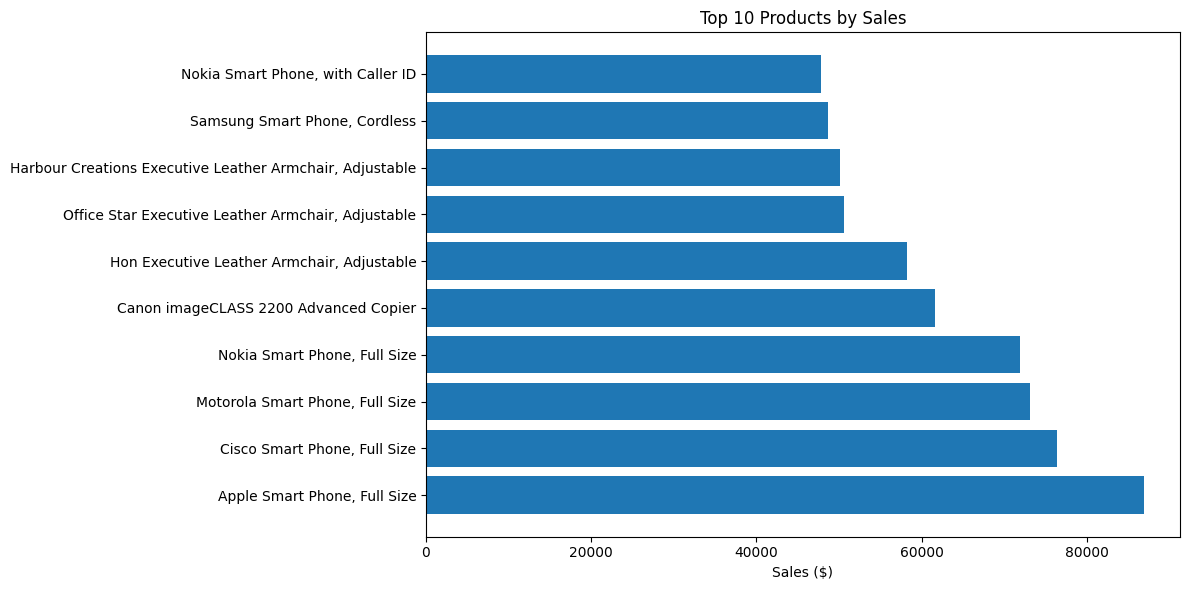

In [55]:
plt.figure(figsize=(12,6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Sales")

plt.xlabel("Sales ($)")

plt.tight_layout()

plt.show()